# 12. GPT — Causal Language Model

**Цель:** Реализовать GPT-подобную модель (Decoder-only), различные стратегии сэмплирования (greedy, top-k, top-p, temperature) и генерацию текста.

---

In [1]:
# top-k: фиксированное число токенов; top-p (nucleus): адаптивное отсечение хвоста распределения; temperature: масштабирование logits
# Взаимодействие: temperature размягчает/ужесточает распределение, затем top-k/p фильтрует токены
import sys, os, logging, math
LOG_LEVEL = os.getenv("LOG_LEVEL", "DEBUG")
logging.basicConfig(level=getattr(logging, LOG_LEVEL), format="%(asctime)s [%(levelname)s] %(name)s: %(message)s", stream=sys.stderr)
log = logging.getLogger("gpt")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Using device: %s", device)

2026-05-31 11:24:30,504 [DEBUG] matplotlib: matplotlib data path: /Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data
2026-05-31 11:24:30,513 [DEBUG] matplotlib: CONFIGDIR=/Users/demanbudaev/.matplotlib
2026-05-31 11:24:30,518 [DEBUG] matplotlib: interactive is False
2026-05-31 11:24:30,518 [DEBUG] matplotlib: platform is darwin
2026-05-31 11:24:30,551 [DEBUG] matplotlib: CACHEDIR=/Users/demanbudaev/.matplotlib
2026-05-31 11:24:30,553 [DEBUG] matplotlib.font_manager: Using fontManager instance from /Users/demanbudaev/.matplotlib/fontlist-v390.json
2026-05-31 11:24:30,691 [INFO] gpt: Using device: mps


## 12.1 GPT-архитектура (Decoder-only)

**Отличие от полного трансформера:**
- Только декодерные блоки (без cross-attention)
- Каузальный self-attention (нельзя заглядывать в будущее)
- Авторегрессивная генерация: каждый новый токен зависит от предыдущих

In [3]:
# Causal LM (авторегрессия): каждый токен предсказывает следующий, masked self-attention
# не позволяет токену заглядывать в будущие позиции — только предыдущие токены
log.debug("Implementing GPT model")

BOS, EOS, PAD = 0, 1, 2

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, Q, K, V, causal=True, pad_mask=None):
        batch = Q.size(0)
        n_heads = self.W_O.out_features // self.d_k
        Q = self.W_Q(Q).view(batch, -1, n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(batch, -1, n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(batch, -1, n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if causal:
            seq_len = Q.size(-2)
            causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=Q.device), diagonal=1).bool()
            scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float('-inf'))
        
        if pad_mask is not None:
            scores = scores.masked_fill(pad_mask.unsqueeze(1).unsqueeze(2) == 0, float('-inf'))
        
        attn = self.dropout(F.softmax(scores, dim=-1))
        output = torch.matmul(attn, V).transpose(1, 2).contiguous().view(batch, -1, self.W_O.out_features)
        return self.W_O(output)

class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 4 * d_model)
        self.fc2 = nn.Linear(4 * d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, x, pad_mask=None):
        x = x + self.dropout1(self.attention(self.norm1(x), self.norm1(x), self.norm1(x), causal=True, pad_mask=pad_mask))
        x = x + self.dropout2(self.ffn(self.norm2(x)))
        return x

class GPT(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, num_layers=6, max_len=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
        self.dropout_pe = nn.Dropout(dropout)
        
        self.layers = nn.ModuleList([
            DecoderBlock(d_model, n_heads, dropout) for _ in range(num_layers)
        ])
        
        self.output_proj = nn.Linear(d_model, vocab_size)
        
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        
        log.info("GPT: vocab=%d, d_model=%d, n_heads=%d, layers=%d, params=%d",
                 vocab_size, d_model, n_heads, num_layers, sum(p.numel() for p in self.parameters()))
    
    def forward(self, x, pad_mask=None):
        x = self.dropout_pe(self.embedding(x) * math.sqrt(self.d_model) + self.pe[:, :x.size(1), :])
        for layer in self.layers:
            x = layer(x, pad_mask)
        return self.output_proj(x)

2026-05-31 11:24:38,777 [DEBUG] gpt: Implementing GPT model


## 12.2 Стратегии сэмплирования

| Метод | Описание |
|-------|----------|
| Greedy | argmax — всегда самый вероятный токен |
| Top-k | Выбор из k наиболее вероятных токенов |
| Top-p (nucleus) | Выбор из токенов с кумулятивной вероятностью p |
| Temperature | Масштабирование logits перед softmax |

### Softmax with Temperature

$$P(x_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

где $z_i$ — logits (выход модели), $T$ — температура. При $T \to 0$ распределение стремится
к one-hot (argmax), при $T \to \infty$ — к равномерному.


### Top-p (nucleus) sampling: отсечение хвоста распределения

В отличие от top-k (фиксированное количество токенов), top-p динамически выбирает минимальное
множество токенов, кумулятивная вероятность которых превышает порог $p$. Это позволяет модели
адаптироваться:
- Когда распределение острое (один токен доминирует) — берётся мало токенов
- Когда распределение плоское — берётся больше токенов
Top-p более гибок, чем top-k, так как не требует ручного подбора k.


### Temperature: размягчение распределения softmax

Temperature масштабирует logits перед softmax:
- **$T < 1$**: распределение становится "острее" — вероятности концентрируются на нескольких токенах
- **$T = 1$**: исходное распределение softmax
- **$T > 1$**: распределение "сглаживается" — низкие вероятности повышаются, высокие понижаются
На практике: low temperature (0.7–0.9) для точных задач, high temperature (1.2–1.5) для креативных.


### Greedy vs Sampling: trade-off качество vs разнообразие

- **Greedy (argmax)**: всегда выбирает самый вероятный токен. Детерминирован, выдаёт связный текст,
  но склонен к повторениям (repetition loops) и предсказуемости.
- **Sampling**: выбирает токен случайно согласно распределению. Разнообразнее, креативнее,
  но может порождать incoherent (несвязные) фрагменты.
Компромисс: комбинировать методы — top-k + top-p + temperature.


In [4]:
# Temperature: softmax(T) = exp(x/T) / sum(exp(x/T)), higher T = more uniform distribution
# Top-p (nucleus) sampling: сортируем вероятности по убыванию, берём минимальное множество
#   токенов, кумулятивная вероятность которых превышает порог p; остальным зануляем prob
log.debug("Implementing sampling strategies")

@torch.no_grad()
def generate_greedy(model, input_ids, max_new_tokens=20):
    model.eval()
    for _ in range(max_new_tokens):
        logits = model(input_ids)[:, -1, :]
        next_token = logits.argmax(-1, keepdim=True)
        input_ids = torch.cat([input_ids, next_token], dim=-1)
        if (next_token == EOS).all():
            break
    return input_ids

@torch.no_grad()
def generate_top_k(model, input_ids, k=10, max_new_tokens=20):
    model.eval()
    for _ in range(max_new_tokens):
        logits = model(input_ids)[:, -1, :]
        # Filter: только top-k
        values, indices = torch.topk(logits, k, dim=-1)
        probs = F.softmax(values, dim=-1)
        next_token = indices.gather(-1, torch.multinomial(probs, 1))
        input_ids = torch.cat([input_ids, next_token], dim=-1)
        if (next_token == EOS).all():
            break
    return input_ids

@torch.no_grad()
def generate_top_p(model, input_ids, p=0.9, max_new_tokens=20):
    model.eval()
    for _ in range(max_new_tokens):
        logits = model(input_ids)[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        
        # Sort by probability descending
        sorted_probs, sorted_indices = probs.sort(descending=True, dim=-1)
        cumsum = sorted_probs.cumsum(dim=-1)
        
        # Remove tokens with cumulative prob > p
        mask = cumsum - sorted_probs > p
        sorted_probs[mask] = 0
        sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
        
        next_token = sorted_indices.gather(-1, torch.multinomial(sorted_probs, 1))
        input_ids = torch.cat([input_ids, next_token], dim=-1)
        if (next_token == EOS).all():
            break
    return input_ids

@torch.no_grad()
def generate_with_temp(model, input_ids, temperature=1.0, max_new_tokens=20):
    model.eval()
    for _ in range(max_new_tokens):
        logits = model(input_ids)[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1)
        input_ids = torch.cat([input_ids, next_token], dim=-1)
        if (next_token == EOS).all():
            break
    return input_ids

log.debug("All sampling strategies defined")

2026-05-31 11:24:49,753 [DEBUG] gpt: Implementing sampling strategies
2026-05-31 11:24:49,754 [DEBUG] gpt: All sampling strategies defined


## 12.3 Демонстрация: сравнение стратегий

Обучим маленький GPT на синтетических данных и сравним все 4 подхода.

2026-05-31 11:24:57,838 [INFO] gpt: Preparing data and training GPT
2026-05-31 11:24:57,899 [INFO] gpt: GPT: vocab=20, d_model=32, n_heads=4, layers=4, params=51604
2026-05-31 11:25:02,725 [INFO] gpt: Epoch 0: loss=3.8279
2026-05-31 11:25:05,990 [INFO] gpt: Epoch 10: loss=2.7932
2026-05-31 11:25:09,219 [INFO] gpt: Epoch 20: loss=2.7567
2026-05-31 11:25:12,146 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-31 11:25:12,147 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-31 11:25:12,149 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-05-31 11:25:12,150 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='itali

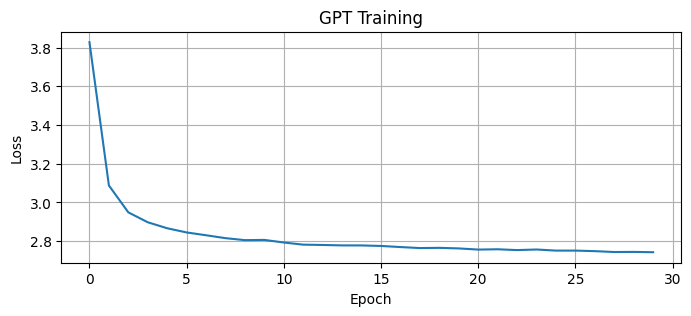

2026-05-31 11:25:13,324 [INFO] gpt: GPT training complete, final loss=2.7431


In [5]:
# Temperature < 1: распределение острее (peakier), модель увереннее; T > 1: равномернее (хаотичнее)
# T=0 эквивалент greedy (argmax), T=inf => uniform random
log.info("Preparing data and training GPT")

vocab_size = 20
max_len = 10

def make_data(num_samples):
    data = []
    for _ in range(num_samples):
        length = np.random.randint(3, max_len - 1)
        seq = [BOS] + np.random.randint(3, vocab_size, size=length).tolist() + [EOS]
        seq = seq + [PAD] * (max_len - len(seq))
        data.append(seq)
    return torch.tensor(data)

train_data = make_data(2000)

gpt = GPT(vocab_size=vocab_size, d_model=32, n_heads=4, num_layers=4, max_len=max_len).to(device)
optimizer = torch.optim.AdamW(gpt.parameters(), lr=0.001)

n_epochs = 30
batch_size = 64
criterion = nn.CrossEntropyLoss(ignore_index=PAD)
losses = []

for epoch in range(n_epochs):
    epoch_loss = 0
    perm = torch.randperm(len(train_data))
    for i in range(0, len(train_data), batch_size):
        idx = perm[i:i+batch_size]
        batch = train_data[idx].to(device)
        
        # GPT: input = batch[:, :-1], target = batch[:, 1:]
        output = gpt(batch[:, :-1])
        loss = criterion(output.reshape(-1, vocab_size), batch[:, 1:].reshape(-1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / (len(train_data) / batch_size)
    losses.append(avg_loss)
    if epoch % 10 == 0:
        log.info("Epoch %d: loss=%.4f", epoch, avg_loss)

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GPT Training')
plt.grid(True)
plt.show()
log.info("GPT training complete, final loss=%.4f", losses[-1])

In [6]:
# Greedy: детерминированный argmax — качественный но repetitively; Sampling: разнообразие но риск incoherence
log.debug("Comparing sampling strategies")

prompt = torch.tensor([[BOS, 5, 12, 8]])  # 4 токена промпта

strategies = {
    'Greedy': lambda: generate_greedy(gpt, prompt.clone(), max_new_tokens=15),
    'Top-k (k=5)': lambda: generate_top_k(gpt, prompt.clone(), k=5, max_new_tokens=15),
    'Top-p (p=0.9)': lambda: generate_top_p(gpt, prompt.clone(), p=0.9, max_new_tokens=15),
    'Temp=0.8': lambda: generate_with_temp(gpt, prompt.clone(), temperature=0.8, max_new_tokens=15),
    'Temp=1.5': lambda: generate_with_temp(gpt, prompt.clone(), temperature=1.5, max_new_tokens=15),
}

for name, fn in strategies.items():
    result = fn()
    tokens = [t for t in result[0].tolist() if t not in (BOS, EOS, PAD)]
    print(f"{name:20s}: {tokens}")
    log.debug("Strategy %s: %s", name, tokens)

log.info("Sampling comparison complete")

2026-05-31 11:25:30,455 [DEBUG] gpt: Comparing sampling strategies


RuntimeError: Placeholder storage has not been allocated on MPS device!

## 12.4 Визуализация: влияние temperature

Temperature контролирует "креативность" генерации: низкая T → детерминировано, высокая T → хаотично.

2026-05-31 11:25:44,395 [DEBUG] gpt: Visualizing temperature effect on probability distribution
2026-05-31 11:25:45,375 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=8.0.
2026-05-31 11:25:45,376 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-05-31 11:25:45,376 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Oblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 1.05
2026-05-31 11:25:45,376 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry

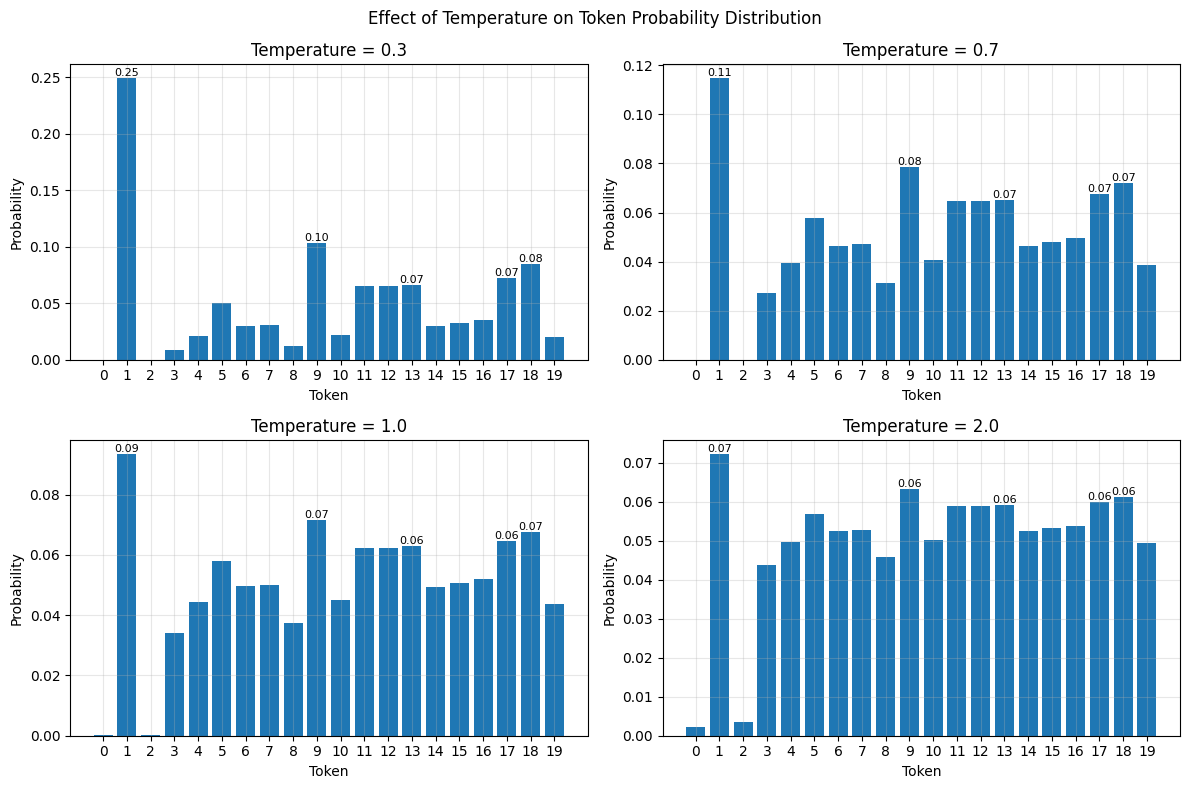

2026-05-31 11:25:45,775 [INFO] gpt: Temperature visualization complete


In [7]:
# Temperature effect: low T (0.3) — почти argmax; T=1 — исходное softmax; high T (2.0) — почти uniform
log.debug("Visualizing temperature effect on probability distribution")

temps = [0.3, 0.7, 1.0, 2.0]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

@torch.no_grad()
def get_probs(model, input_ids, temp):
    logits = model(input_ids)[:, -1, :]
    return F.softmax(logits / temp, dim=-1)[0].cpu().numpy()

for ax, temp in zip(axes.flat, temps):
    probs = get_probs(gpt, prompt.to(device), temp)
    ax.bar(range(vocab_size), probs)
    ax.set_title(f'Temperature = {temp}')
    ax.set_xlabel('Token')
    ax.set_ylabel('Probability')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(vocab_size))
    
    top5 = probs.argsort()[-5:][::-1]
    for t in top5:
        ax.text(t, probs[t], f'{probs[t]:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Effect of Temperature on Token Probability Distribution')
plt.tight_layout()
plt.show()
log.info("Temperature visualization complete")

In [8]:
# Итог: top-k фиксирует число кандидатов, top-p адаптируется к форме распределения, температура сглаживает
print("=== GPT (Causal Language Model) complete ===")
print("Topics covered:")
print("  - GPT architecture (Decoder-only, causal attention)")
print("  - Autoregressive generation loop")
print("  - Greedy decoding (argmax)")
print("  - Top-k sampling")
print("  - Top-p (nucleus) sampling")
print("  - Temperature scaling")
print("  - Comparison of all strategies")
log.info("GPT notebook complete")

2026-05-31 11:25:52,661 [INFO] gpt: GPT notebook complete


=== GPT (Causal Language Model) complete ===
Topics covered:
  - GPT architecture (Decoder-only, causal attention)
  - Autoregressive generation loop
  - Greedy decoding (argmax)
  - Top-k sampling
  - Top-p (nucleus) sampling
  - Temperature scaling
  - Comparison of all strategies


📚 **Полезные ссылки:**
- [Language Models are Unsupervised Multitask Learners (GPT-2, Radford et al., 2019)](https://d4mucfpksywv.cloudfront.net/better-language-models/language-models.pdf)
- [The Curious Case of Neural Text Degeneration (Holtzman et al., 2020) — top-p sampling](https://arxiv.org/abs/1904.09751)
- [Hierarchical Neural Story Generation (Fan et al., 2018) — top-k sampling](https://arxiv.org/abs/1805.04833)
